In [1]:
from qiskit import QuantumCircuit
import numpy as np

In [2]:
# this returns a Quantumcircuit object to return
# n inputs plus one output qubit 
def dj_oracle(case,n):
    oracle_qc = QuantumCircuit(n+1)
    #output qubit is the target 
    if case=="balanced":
        for qubit in range(n):
            oracle_qc.cx(qubit, n)
    if case=="constant":
        output=np.random.randint(2)
        if output==1:
            oracle_qc.x(n)
    oracle_gate = oracle_qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

In [3]:
def dj_algorithm(n,case="random"):
    dj_circuit = QuantumCircuit(n+1,n) # n+1 quantum qubits inputs and n classical inputs to measure at the end
    for qubit in range(n):
        dj_circuit.h(qubit)
    #for output qubit
    dj_circuit.x(n)
    dj_circuit.h(n) # x + h --> gives u |-> state
    if case=="random":
        r = np.random.randint(2)
        if r==1:
            case="balanced"
        else:
            case="constant"
    oracle = dj_oracle(case,n)
    dj_circuit.append(oracle,range(n+1)) 
    for i in range(n):
        dj_circuit.h(i)
        dj_circuit.measure(i,i) 
    return dj_circuit

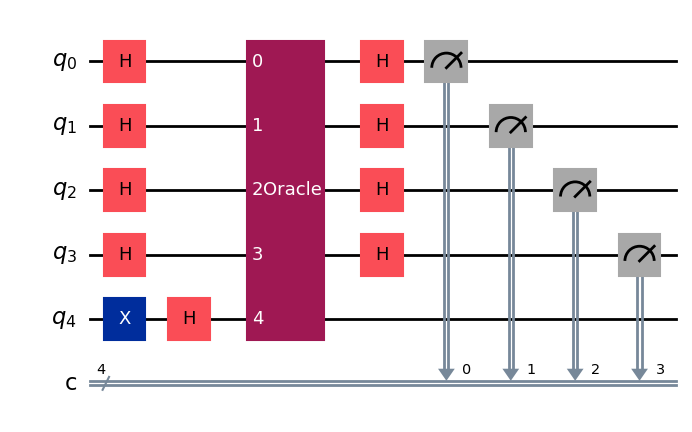

In [5]:
n = 4
dj_circuit = dj_algorithm(n)
dj_circuit.draw(output="mpl")

In [9]:
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

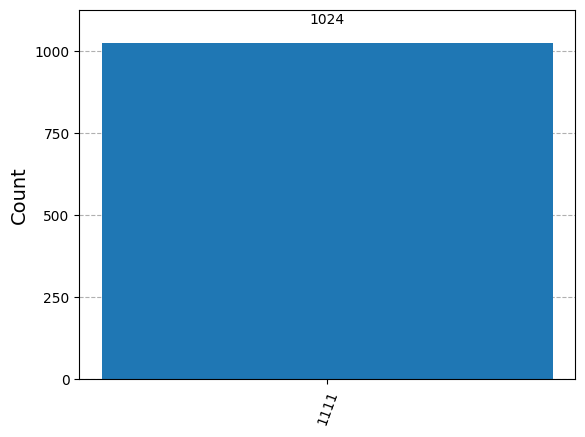

In [ ]:
from qiskit import transpile
backend = AerSimulator()
dj_circuit = dj_algorithm(n)  
transpiled_circuit = transpile(dj_circuit, backend)
shots = 1024
job = backend.run(transpiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_quantum")

In [ ]:
backend = service.least_busy(
    filters=lambda b:(
        b.configuration().n_qubits >= n 
        and not b.configuration().simulator
        and b.status().operational
    )
)
print("Least bbusy backend name: ",backend.name)    
dj_circuit = dj_algorithm(n)
transpiled_circuit = transpile(dj_circuit,backend=backend,optimization_level=3)

Least bbusy backend name:  ibm_kyiv


In [26]:
from qiskit_ibm_runtime import Sampler
sampler = Sampler(mode=backend)
shots = 1024
job = sampler.run([transpiled_circuit], shots=shots)
result = job.result()



SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=4>)), metadata={'circuit_metadata': {}})


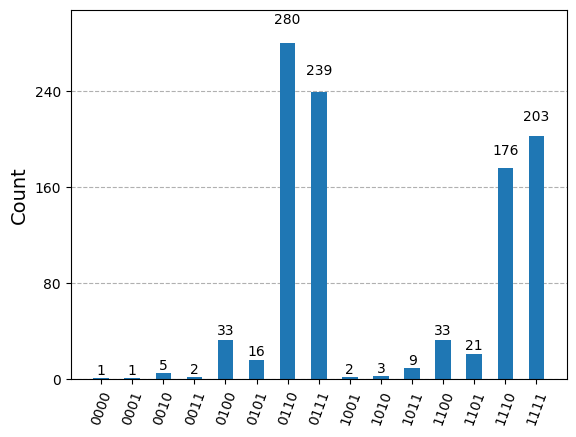

In [37]:
# Access the first (and only) result
first_result = result[0]
print(first_result)
# Convert the DataBin to a counts dictionary
counts = result[0].data.c.get_counts()
plot_histogram(counts)


### Because the result is heavily peaked on these four outcomes, the final measurement isn’t the all-zeros string. This confirms your oracle was balanced (rather than constant).

## Constant case

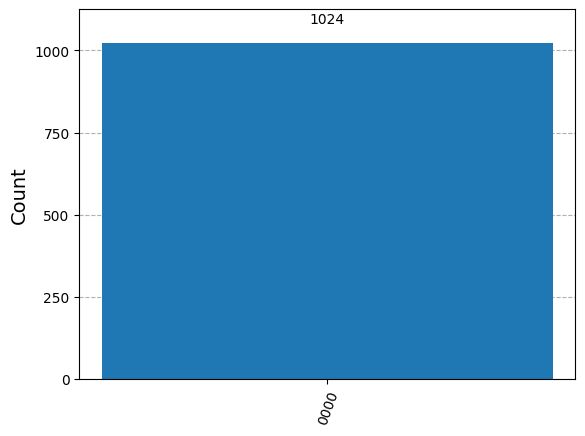

In [44]:
from qiskit import transpile
backend = AerSimulator()
dj_circuit = dj_algorithm(n,case="constant")  # Your Deutsch-Jozsa circuit
transpiled_circuit = transpile(dj_circuit, backend)
shots = 1024
job = backend.run(transpiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)


In [45]:
backend = service.least_busy(
    filters=lambda b:(
        b.configuration().n_qubits >= n 
        and not b.configuration().simulator
        and b.status().operational
    )
)
print("Least bbusy backend name: ",backend.name)
dj_circuit = dj_algorithm(n,case="constant")
transpiled_circuit = transpile(dj_circuit,backend=backend,optimization_level=3)

Least bbusy backend name:  ibm_kyiv


In [46]:
from qiskit_ibm_runtime import Sampler
sampler = Sampler(mode=backend)
shots = 1024
job = sampler.run([transpiled_circuit], shots=shots)
result = job.result()

SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=4>)), metadata={'circuit_metadata': {}})


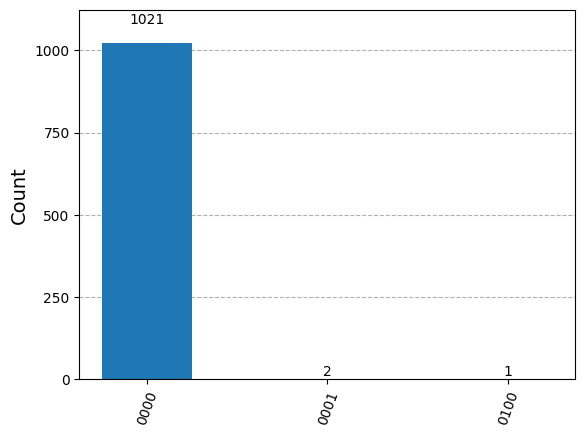

In [47]:
# Access the first (and only) result
first_result = result[0]
print(first_result)
# Convert the DataBin to a counts dictionary
counts = result[0].data.c.get_counts()
plot_histogram(counts)